# Importing requried libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Step 1: Load Dataset

In [23]:
df = pd.read_csv('creditcard.csv')
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

# Step 2: Check Data Balance

C:\Users\Balamurukan S\AppData\Local\Temp\ipykernel_8248\1868482296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['blue', 'red'])


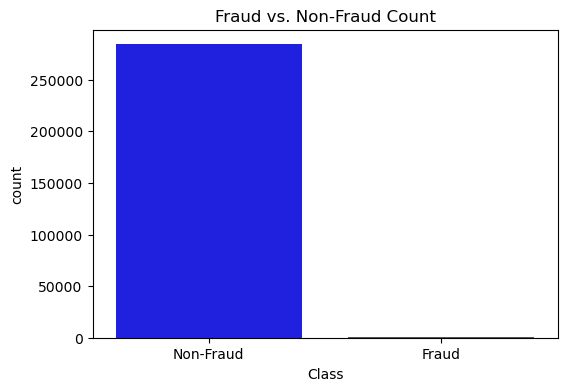

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['blue', 'red'])
plt.title("Fraud vs. Non-Fraud Count")
plt.xticks(ticks=[0,1], labels=['Non-Fraud', 'Fraud'])
plt.show()

Chart highlights the class imbalance problem and its potential implications for predictive modeling, particularly in the context of fraud detection. It visually illustrates the need for careful consideration and appropriate techniques to handle this characteristic of the data.

# Step 3: Transaction Amount Distribution

C:\Users\Balamurukan S\AppData\Local\Temp\ipykernel_8248\3772174391.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Non-Fraud', shade=True, color='blue')
C:\Users\Balamurukan S\AppData\Local\Temp\ipykernel_8248\3772174391.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud', shade=True, color='red')


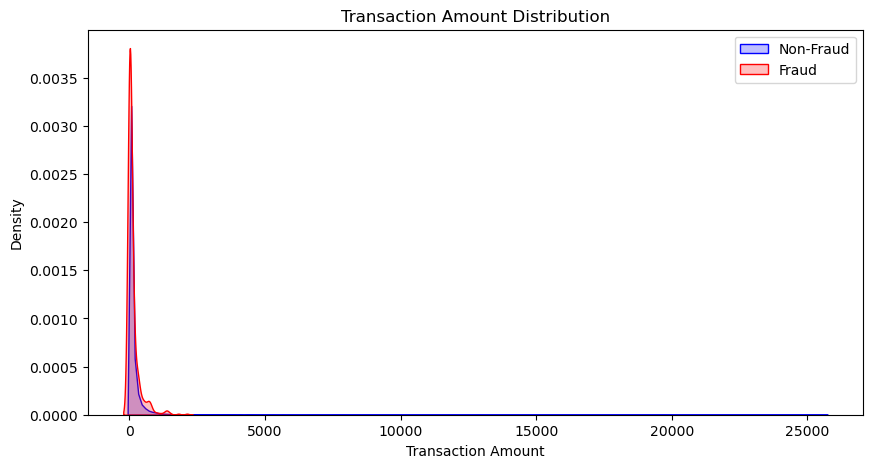

In [25]:
plt.figure(figsize=(10,5))
sns.kdeplot(df[df['Class'] == 0]['Amount'], label='Non-Fraud', shade=True, color='blue')
sns.kdeplot(df[df['Class'] == 1]['Amount'], label='Fraud', shade=True, color='red')
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.legend()
plt.show()

Chart reveals that transaction amount alone is not sufficient to reliably distinguish between fraudulent and non-fraudulent transactions, as both distributions overlap significantly. However, it provides valuable insights into the general patterns of transaction amounts for both classes, suggesting that larger transactions are somewhat more likely to be associated with fraud.  This information can be used to inform feature engineering and model selection in a fraud detection system.

# Step 4: Preprocessing

In [26]:
df['Amount'] = StandardScaler().fit_transform(df[['Amount']])
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Step 5: Handle Imbalance using SMOTE

In [27]:
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


# Step 6: Train Logistic Regression Model

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Logistic Regression Performance:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.10      0.91      0.18        98

    accuracy                           0.99     56962
   macro avg       0.55      0.95      0.59     56962
weighted avg       1.00      0.99      0.99     56962

ROC-AUC Score: 0.9471879916851378


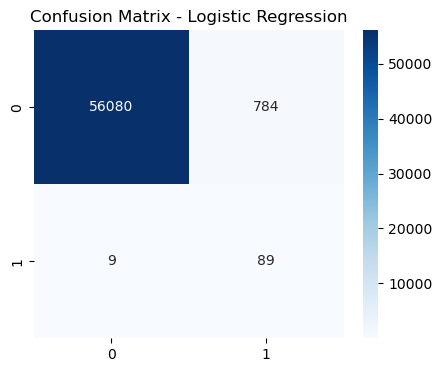

In [28]:
log_reg = LogisticRegression()
log_reg.fit(X_train_resampled, y_train_resampled)
y_pred_lr = log_reg.predict(X_test)
print("\nLogistic Regression Performance:")
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_lr))
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()


# Step 6: Train Random Forest Model


Random Forest Performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.87      0.86        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9335415757467872


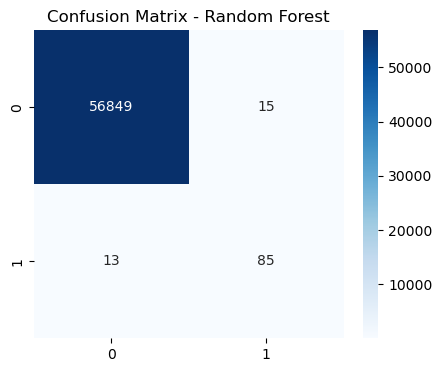

In [29]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf.predict(X_test)
print("\nRandom Forest Performance:")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_rf))
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [3]:
lst = [1,2,5,7,100]

print(sorted(lst))

[1, 2, 5, 7, 100]
